# Notebook 05c：移动机器人运动学

## 1. 定位
NB05-06 覆盖了机械臂运动学。本节补齐移动机器人的运动学模型——差速驱动、独轮车、Ackermann，以及非完整约束的概念。

## 2. 学习目标
- ⭐ 差速驱动机器人的正/逆运动学
- ⭐ 独轮车模型与非完整约束
- ⭐ Pure Pursuit 路径跟踪
- 📖 轮式里程计误差模型

## 3. 差速驱动模型 ⭐

两轮差速机器人：
$$v = \frac{r}{2}(\dot{\phi}_L + \dot{\phi}_R), \quad \omega = \frac{r}{L}(\dot{\phi}_R - \dot{\phi}_L)$$

状态方程（独轮车）：
$$\dot{x} = v\cos\theta, \quad \dot{y} = v\sin\theta, \quad \dot{\theta} = \omega$$

## 4. Python 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys; sys.path.insert(0, '..')
%matplotlib inline
rng = np.random.RandomState(42)
print("✅ 导入完成")

✅ 导入完成


### 4.1 差速机器人轨迹仿真

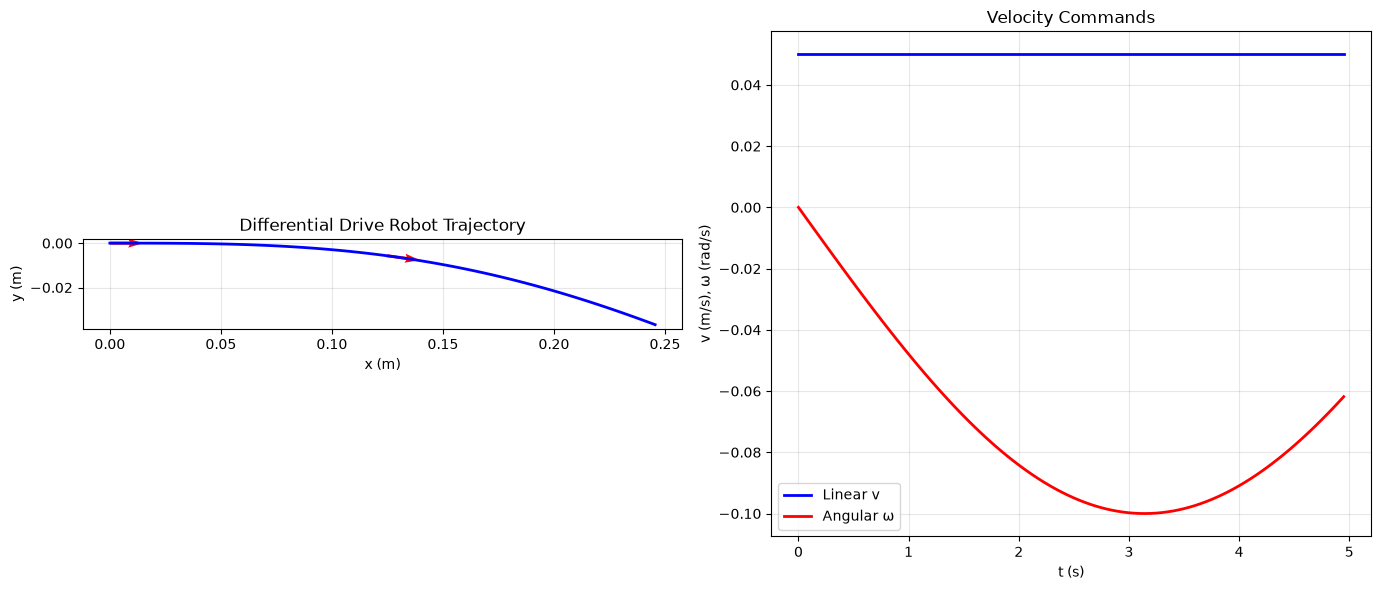

In [2]:
dt_m = 0.05; T_m = 5.0; N_m = int(T_m/dt_m)
wheel_radius = 0.05; wheel_base = 0.3  # 轮距

# 控制：左右轮速度（模拟绕圈）
t_m = np.arange(N_m) * dt_m
v_L = 1.0 + 0.3*np.sin(0.5*t_m)
v_R = 1.0 - 0.3*np.sin(0.5*t_m)
v_robot = wheel_radius/2 * (v_L + v_R)
omega_robot = wheel_radius/wheel_base * (v_R - v_L)

# 前向积分
x, y, theta = 0.0, 0.0, 0.0
x_hist, y_hist, th_hist = [x], [y], [theta]
for k in range(N_m):
    x += v_robot[k] * np.cos(theta) * dt_m
    y += v_robot[k] * np.sin(theta) * dt_m
    theta += omega_robot[k] * dt_m
    x_hist.append(x); y_hist.append(y); th_hist.append(theta)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(x_hist, y_hist, 'b-', linewidth=2)
# 每隔一定步数画机器人朝向
for i in range(0, N_m, 50):
    axes[0].quiver(x_hist[i], y_hist[i], 0.15*np.cos(th_hist[i]), 0.15*np.sin(th_hist[i]),
                   color='red', width=0.005)
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].set_title('Differential Drive Robot Trajectory'); axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_m, v_robot, 'b-', linewidth=2, label='Linear v')
axes[1].plot(t_m, omega_robot, 'r-', linewidth=2, label='Angular ω')
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('v (m/s), ω (rad/s)')
axes[1].set_title('Velocity Commands'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/05c_diff_drive.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.2 Pure Pursuit 路径跟踪

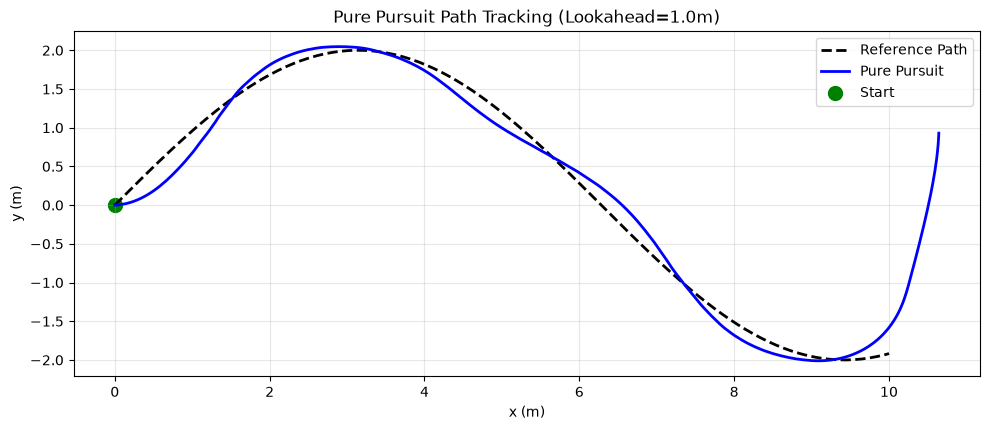

In [3]:
# 参考路径：sin 曲线
path_s = np.linspace(0, 10, 200)
path_x = path_s; path_y = 2*np.sin(0.5*path_s)

# Pure Pursuit: 找前瞻距离 L 处的目标点
L_lookahead = 1.0; dt_pp = 0.05
x_pp, y_pp, theta_pp = 0.0, 0.0, 0.0
xpp_hist, ypp_hist = [x_pp], [y_pp]

for k in range(300):
    # 找路径上距离机器人 L_lookahead 的点
    dists = np.sqrt((path_x-x_pp)**2 + (path_y-y_pp)**2)
    target_idx = np.argmin(np.abs(dists - L_lookahead))
    target_idx = min(target_idx + 1, len(path_x)-1)
    tx, ty = path_x[target_idx], path_y[target_idx]

    # 在机器人坐标系中计算目标方位
    dx, dy = tx-x_pp, ty-y_pp
    alpha = np.arctan2(dy, dx) - theta_pp
    alpha = np.arctan2(np.sin(alpha), np.cos(alpha))

    # 曲率 κ = 2sin(α)/L → 角速度 ω = v*κ
    v_pp = 1.0
    curvature = 2*np.sin(alpha) / L_lookahead
    omega_pp = v_pp * curvature
    omega_pp = np.clip(omega_pp, -1.5, 1.5)

    theta_pp += omega_pp * dt_pp
    x_pp += v_pp * np.cos(theta_pp) * dt_pp
    y_pp += v_pp * np.sin(theta_pp) * dt_pp
    xpp_hist.append(x_pp); ypp_hist.append(y_pp)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(path_x, path_y, 'k--', linewidth=2, label='Reference Path')
ax.plot(xpp_hist, ypp_hist, 'b-', linewidth=2, label='Pure Pursuit')
ax.scatter(0, 0, c='green', s=100, marker='o', label='Start')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title(f'Pure Pursuit Path Tracking (Lookahead={L_lookahead}m)')
ax.set_aspect('equal'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/05c_pure_pursuit.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. 练习题
1. 差速机器人是非完整约束系统——为什么？不能侧移的数学表达？
2. Pure Pursuit 的 lookahead 距离如何影响跟踪性能？